In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
from scipy import stats

import math
from scipy.special import expit 
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = np.load("/kaggle/input/linear-regression-competitive-ml-letovo/task_data.npz")
X = data["X"]
p_vasya = data["p_vasya"]
print(f"X shape: {X.shape}")
print(f"p_vasya shape: {p_vasya.shape}")
print(f"X dtype: {X.dtype}, p_vasya dtype: {p_vasya.dtype}")
print(f"Sample X[0]: {X[0]}")
print(f"Sample p_vasya[0]: {p_vasya[0]}")
p_vasya_norm = p_vasya / p_vasya.max()
print(f"Normalized p_vasya stats: Min {p_vasya_norm.min():.4f}, Max {p_vasya_norm.max():.4f}, Mean {p_vasya_norm.mean():.4f}")

X shape: (2000, 15)
p_vasya shape: (2000,)
X dtype: float64, p_vasya dtype: float64
Sample X[0]: [ 3.97685555e-01 -1.91013584e-01  6.18337118e-01  1.53051330e+00
 -1.82945258e-01 -1.99430160e-01  1.52024658e+00  7.48849116e-01
 -4.65655606e-01  5.29449687e-01  3.67309824e-01  5.96306790e-01
  9.09033304e-04 -1.93342724e+00 -1.87957912e+00]
Sample p_vasya[0]: 1983.9999755679498
Normalized p_vasya stats: Min 0.0000, Max 1.0000, Mean 0.7728


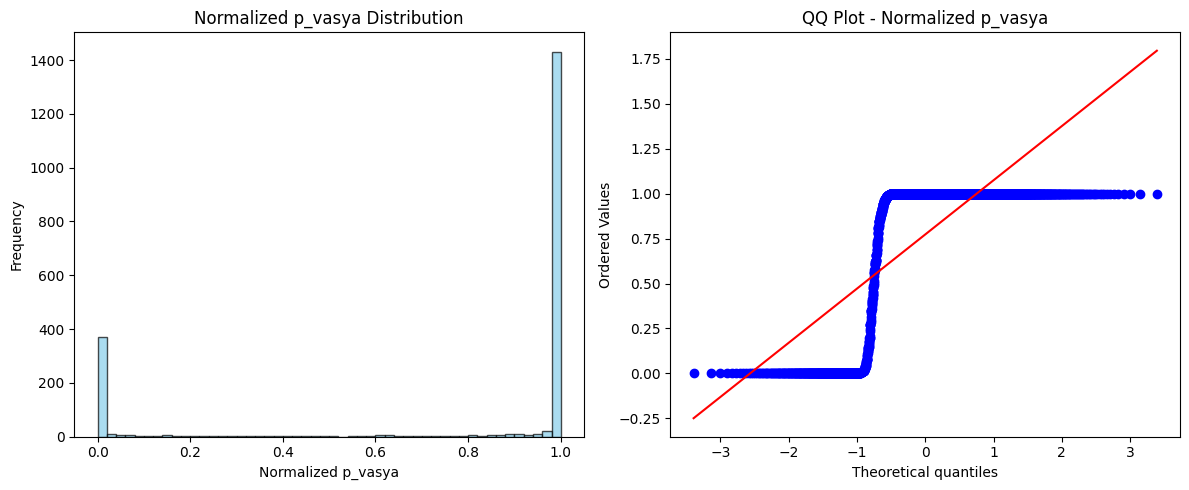

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(p_vasya_norm, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_title('Normalized p_vasya Distribution')
axes[0].set_xlabel('Normalized p_vasya')
axes[0].set_ylabel('Frequency')

# QQ Plot
stats.probplot(p_vasya_norm, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot - Normalized p_vasya')

plt.tight_layout()
plt.show()


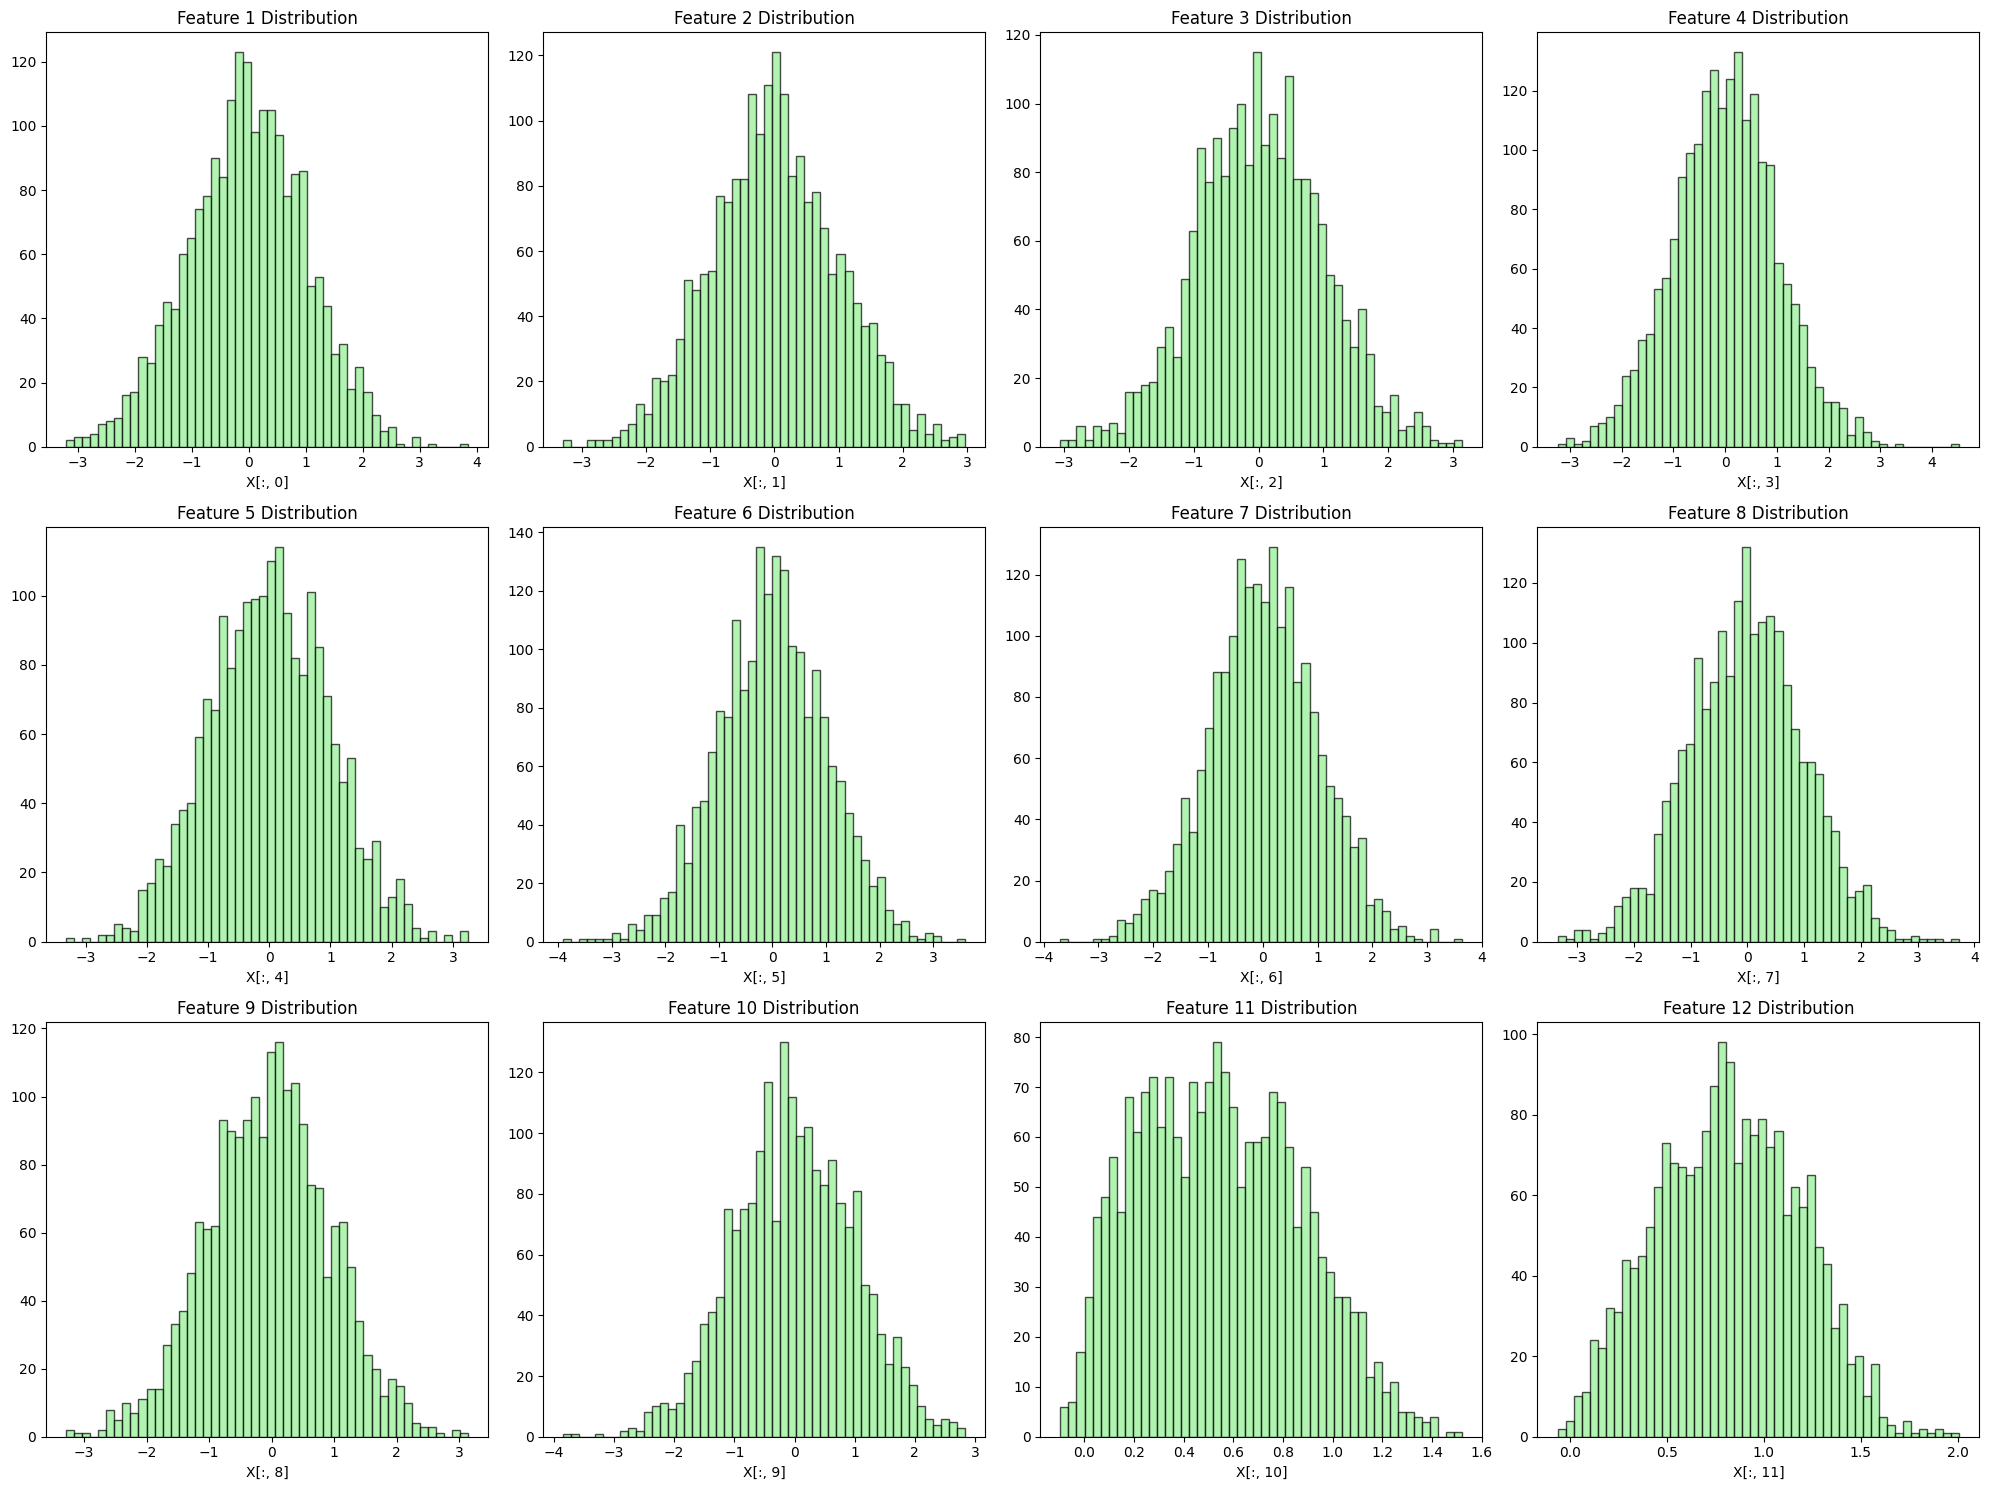

In [4]:
n_features_show = min(12, X.shape[1])
n_cols = 4
n_rows = (n_features_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

for i in range(n_features_show):
    row, col = i // n_cols, i % n_cols
    axes[row, col].hist(X[:, i], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[row, col].set_title(f'Feature {i+1} Distribution')
    axes[row, col].set_xlabel(f'X[:, {i}]')

# Hide empty subplots
for i in range(n_features_show, n_rows * n_cols):
    row, col = i // n_cols, i % n_cols
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()

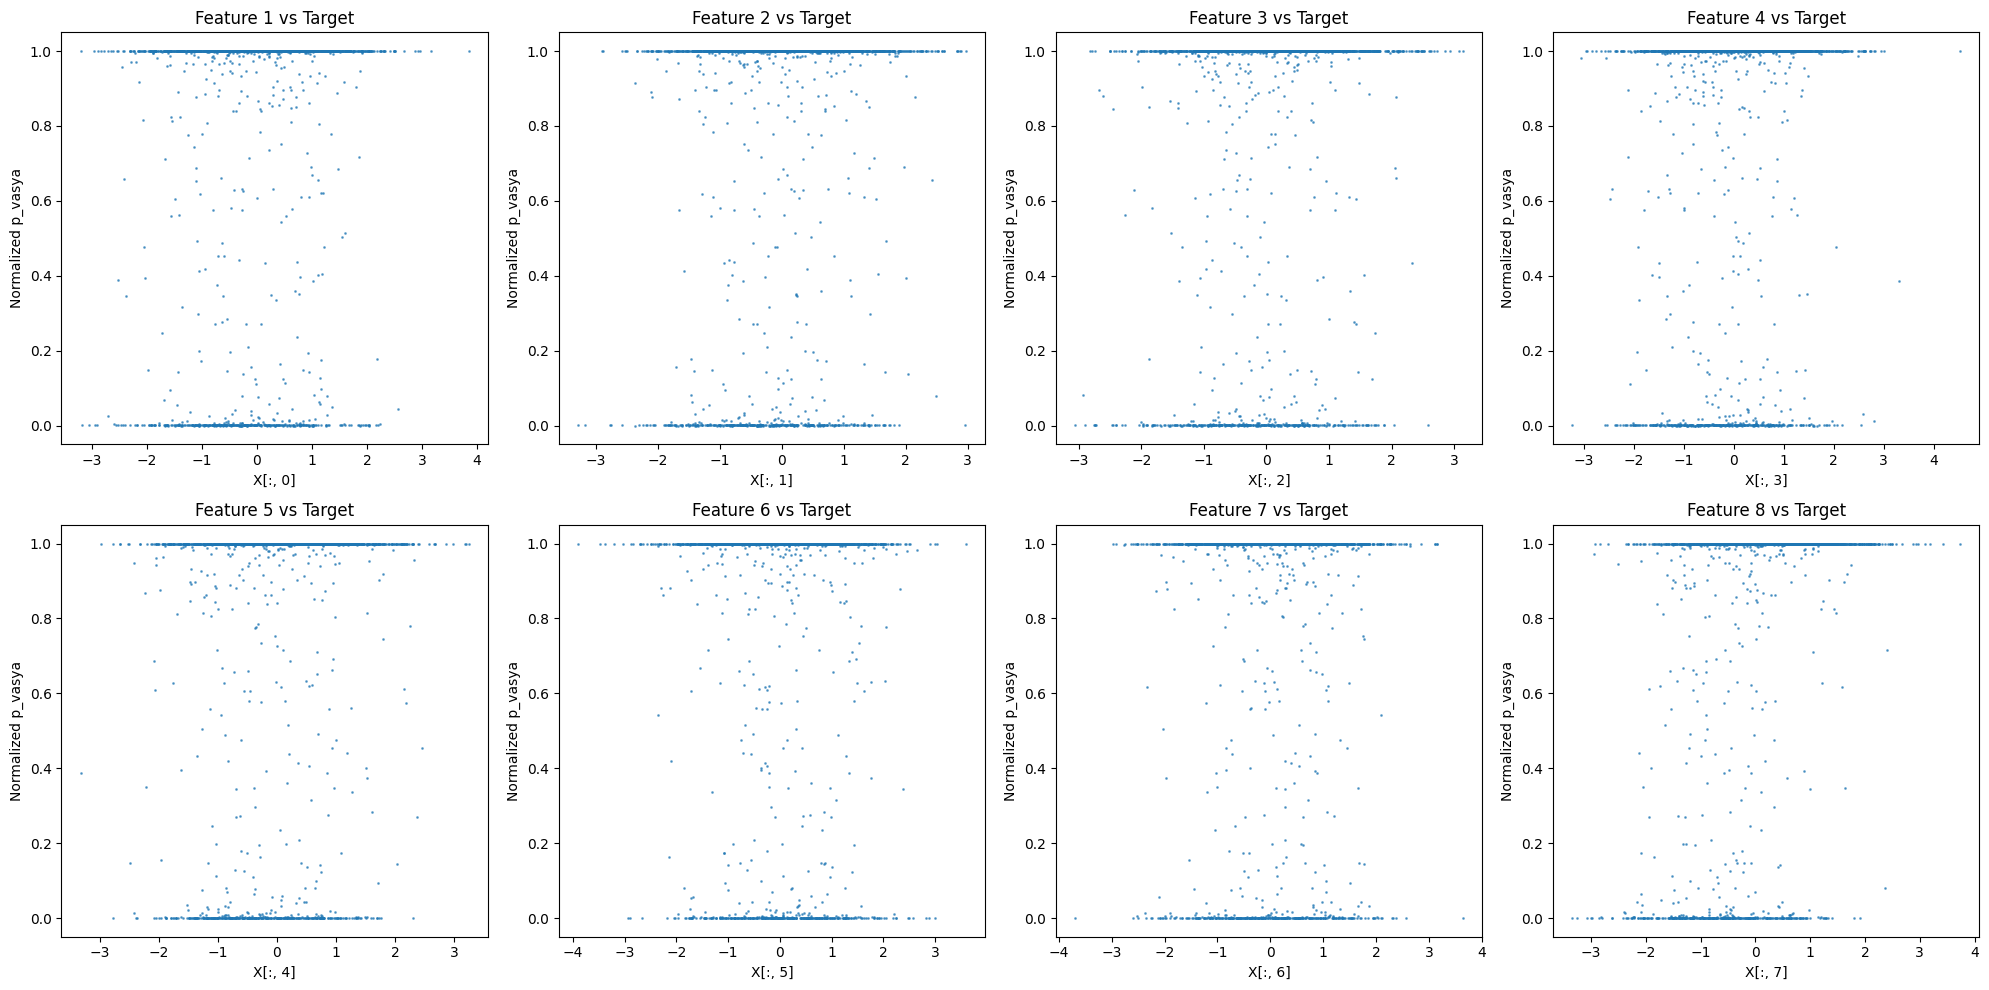

In [5]:
n_features_show = min(8, X.shape[1])
n_cols = 4
n_rows = (n_features_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for i in range(n_features_show):
    row, col = i // n_cols, i % n_cols
    axes[row, col].scatter(X[:, i], p_vasya_norm, alpha=0.6, s=1)
    axes[row, col].set_title(f'Feature {i+1} vs Target')
    axes[row, col].set_xlabel(f'X[:, {i}]')
    axes[row, col].set_ylabel('Normalized p_vasya')

# Hide empty subplots
for i in range(n_features_show, n_rows * n_cols):
    row, col = i // n_cols, i % n_cols
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()

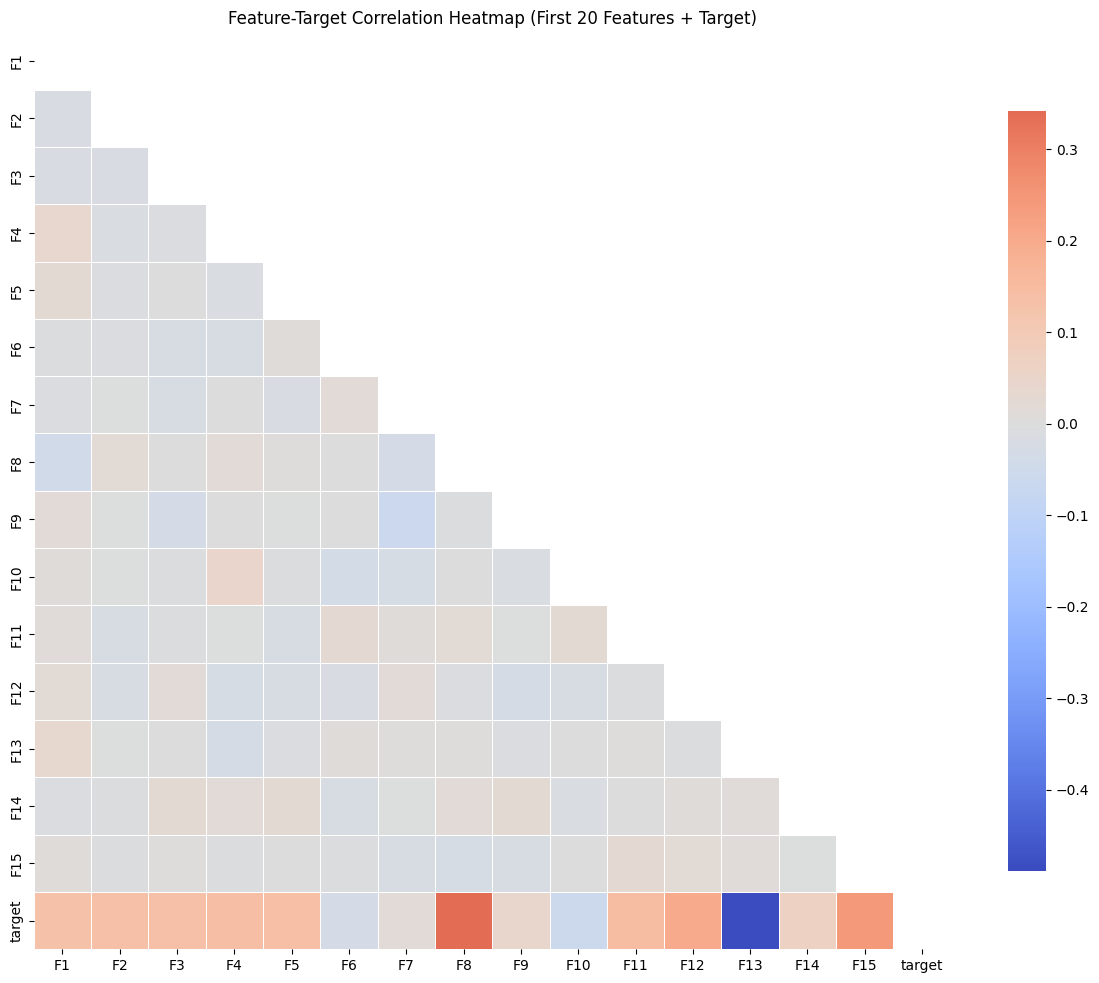

In [6]:
# Create DataFrame for correlation
feature_names = [f'F{i+1}' for i in range(X.shape[1])]
df_corr = pd.DataFrame(X, columns=feature_names)
df_corr['target'] = p_vasya_norm

corr_matrix = df_corr.corr()

# Plot heatmap (sample first 20 features if too many)
n_features_heatmap = min(20, X.shape[1])
sample_cols = feature_names[:n_features_heatmap] + ['target']
corr_sample = corr_matrix.loc[sample_cols, sample_cols]

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_sample, dtype=bool))
sns.heatmap(corr_sample, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Feature-Target Correlation Heatmap (First 20 Features + Target)')
plt.tight_layout()
plt.show()

1. F13: -0.4888
2. F8: +0.3423
3. F15: +0.2404
4. F12: +0.2025
5. F11: +0.1444
6. F4: +0.1438
7. F5: +0.1405
8. F2: +0.1371
9. F3: +0.1342
10. F1: +0.1312


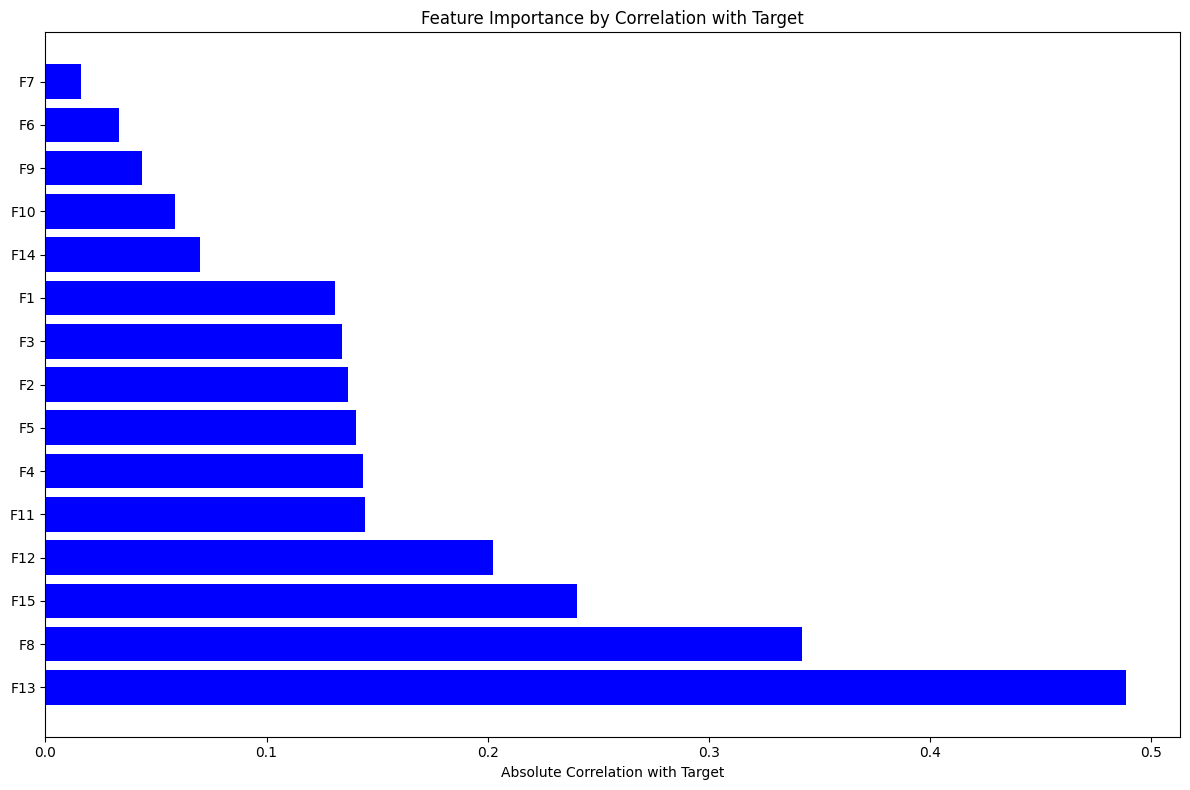

In [7]:
plt.figure(figsize=(12, 8))

feature_corrs = corr_matrix['target'].drop('target')
feature_corrs_sorted = feature_corrs.abs().sort_values(ascending=True)

colors = ['red' if corr < 0 else 'blue' for corr in feature_corrs_sorted.values]
plt.barh(range(len(feature_corrs_sorted)), feature_corrs_sorted.values, color=colors)
plt.yticks(range(len(feature_corrs_sorted)), feature_corrs_sorted.index)
plt.xlabel('Absolute Correlation with Target')
plt.title('Feature Importance by Correlation with Target')
plt.gca().invert_yaxis()

# Show top 10
top_10 = feature_corrs.abs().sort_values(ascending=False).head(10)
for i, (feat, corr) in enumerate(top_10.items()):
    sign = '+' if corr_matrix['target'][feat] > 0 else '-'
    print(f"{i+1}. {feat}: {sign}{corr:.4f}")

plt.tight_layout()
plt.show()

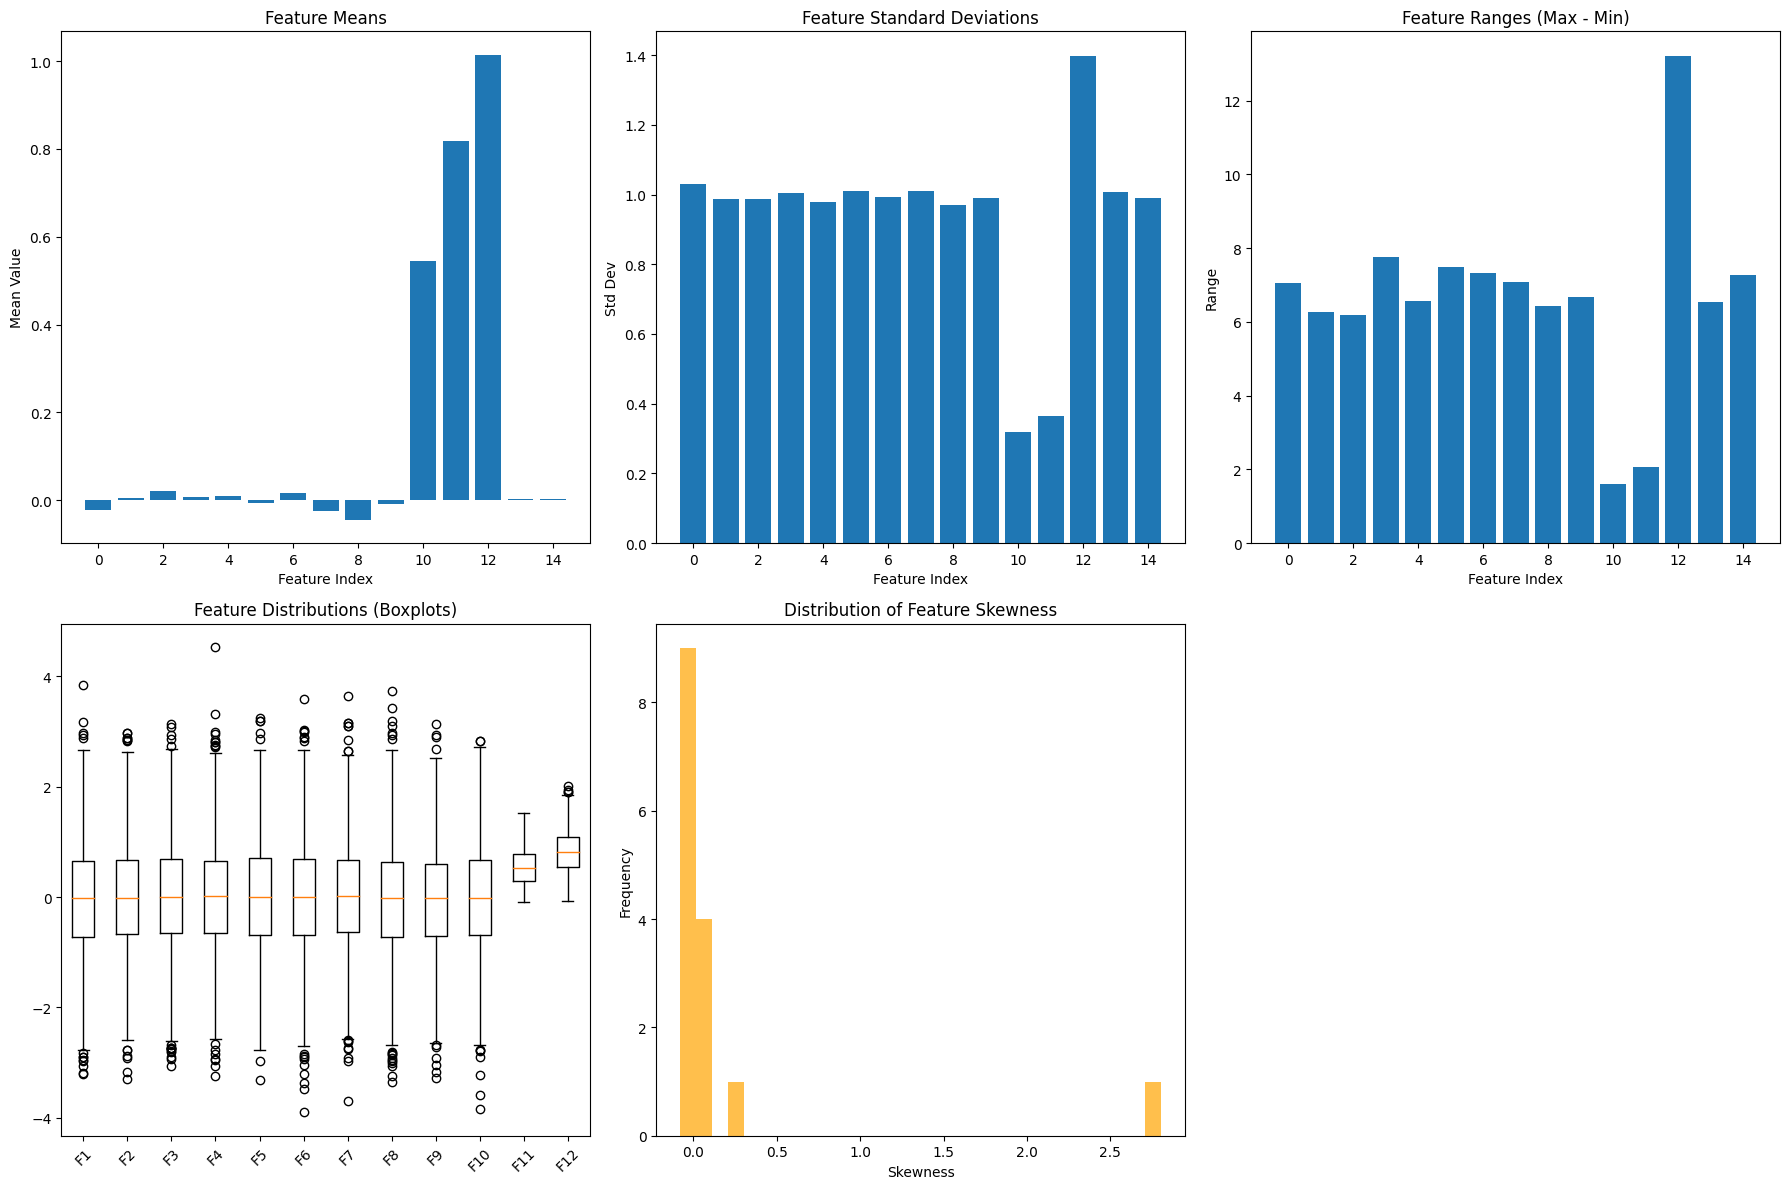

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Feature means
feature_means = np.mean(X, axis=0)
axes[0, 0].bar(range(len(feature_means)), feature_means)
axes[0, 0].set_title('Feature Means')
axes[0, 0].set_xlabel('Feature Index')
axes[0, 0].set_ylabel('Mean Value')

# Feature stds
feature_stds = np.std(X, axis=0)
axes[0, 1].bar(range(len(feature_stds)), feature_stds)
axes[0, 1].set_title('Feature Standard Deviations')
axes[0, 1].set_xlabel('Feature Index')
axes[0, 1].set_ylabel('Std Dev')

# Feature ranges
feature_ranges = np.ptp(X, axis=0)
axes[0, 2].bar(range(len(feature_ranges)), feature_ranges)
axes[0, 2].set_title('Feature Ranges (Max - Min)')
axes[0, 2].set_xlabel('Feature Index')
axes[0, 2].set_ylabel('Range')

# Boxplots (first 12 features)
n_boxplots = min(12, X.shape[1])
box_data = [X[:, i] for i in range(n_boxplots)]
axes[1, 0].boxplot(box_data, labels=[f'F{i+1}' for i in range(n_boxplots)])
axes[1, 0].set_title('Feature Distributions (Boxplots)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Feature skewness
feature_skew = stats.skew(X, axis=0)
axes[1, 1].hist(feature_skew, bins=30, alpha=0.7, color='orange')
axes[1, 1].set_title('Distribution of Feature Skewness')
axes[1, 1].set_xlabel('Skewness')
axes[1, 1].set_ylabel('Frequency')

# Hide empty subplot
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

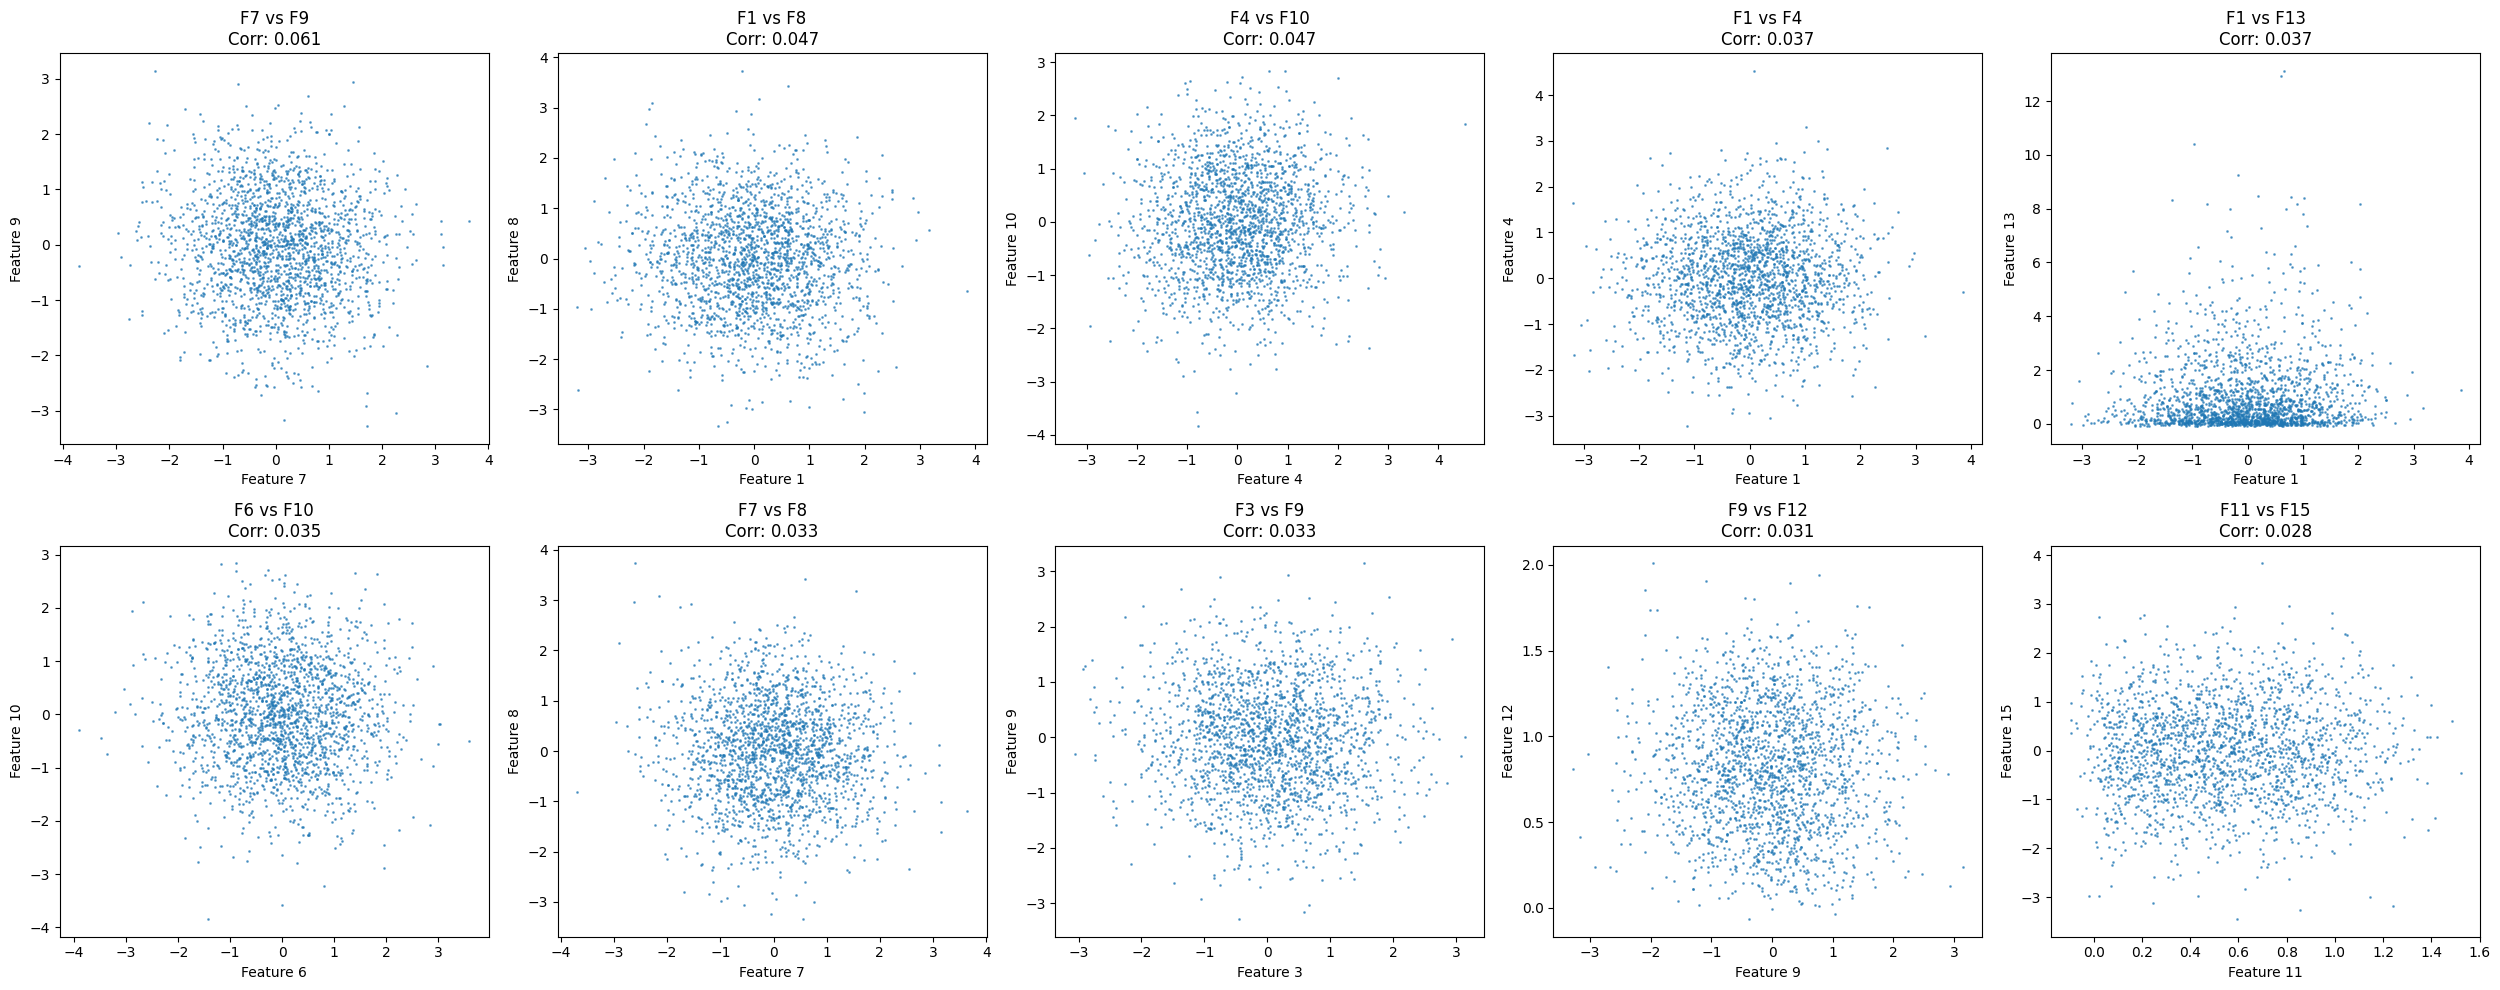

Top 10 feature-feature correlations:
1. F7 vs F9: 0.0606
2. F1 vs F8: 0.0471
3. F4 vs F10: 0.0469
4. F1 vs F4: 0.0374
5. F1 vs F13: 0.0370
6. F6 vs F10: 0.0348
7. F7 vs F8: 0.0332
8. F3 vs F9: 0.0329
9. F9 vs F12: 0.0305
10. F11 vs F15: 0.0282


In [9]:
# Find top pairwise feature correlations
corr_pairs = []
for i in range(X.shape[1]):
    for j in range(i+1, X.shape[1]):
        corr_val = np.corrcoef(X[:, i], X[:, j])[0, 1]
        corr_pairs.append((i, j, abs(corr_val)))

corr_pairs.sort(key=lambda x: x[2], reverse=True)
top_10_pairs = corr_pairs[:10]

n_cols = 5
n_rows = (len(top_10_pairs) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for idx, (i, j, corr_val) in enumerate(top_10_pairs):
    row, col = idx // n_cols, idx % n_cols
    axes[row, col].scatter(X[:, i], X[:, j], alpha=0.6, s=1)
    axes[row, col].set_title(f'F{i+1} vs F{j+1}\nCorr: {corr_val:.3f}')
    axes[row, col].set_xlabel(f'Feature {i+1}')
    axes[row, col].set_ylabel(f'Feature {j+1}')

# Hide empty subplots
for idx in range(len(top_10_pairs), n_rows * n_cols):
    row, col = idx // n_cols, idx % n_cols
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()

print("Top 10 feature-feature correlations:")
for i, (feat1, feat2, corr) in enumerate(top_10_pairs[:10]):
    print(f"{i+1}. F{feat1+1} vs F{feat2+1}: {corr:.4f}")

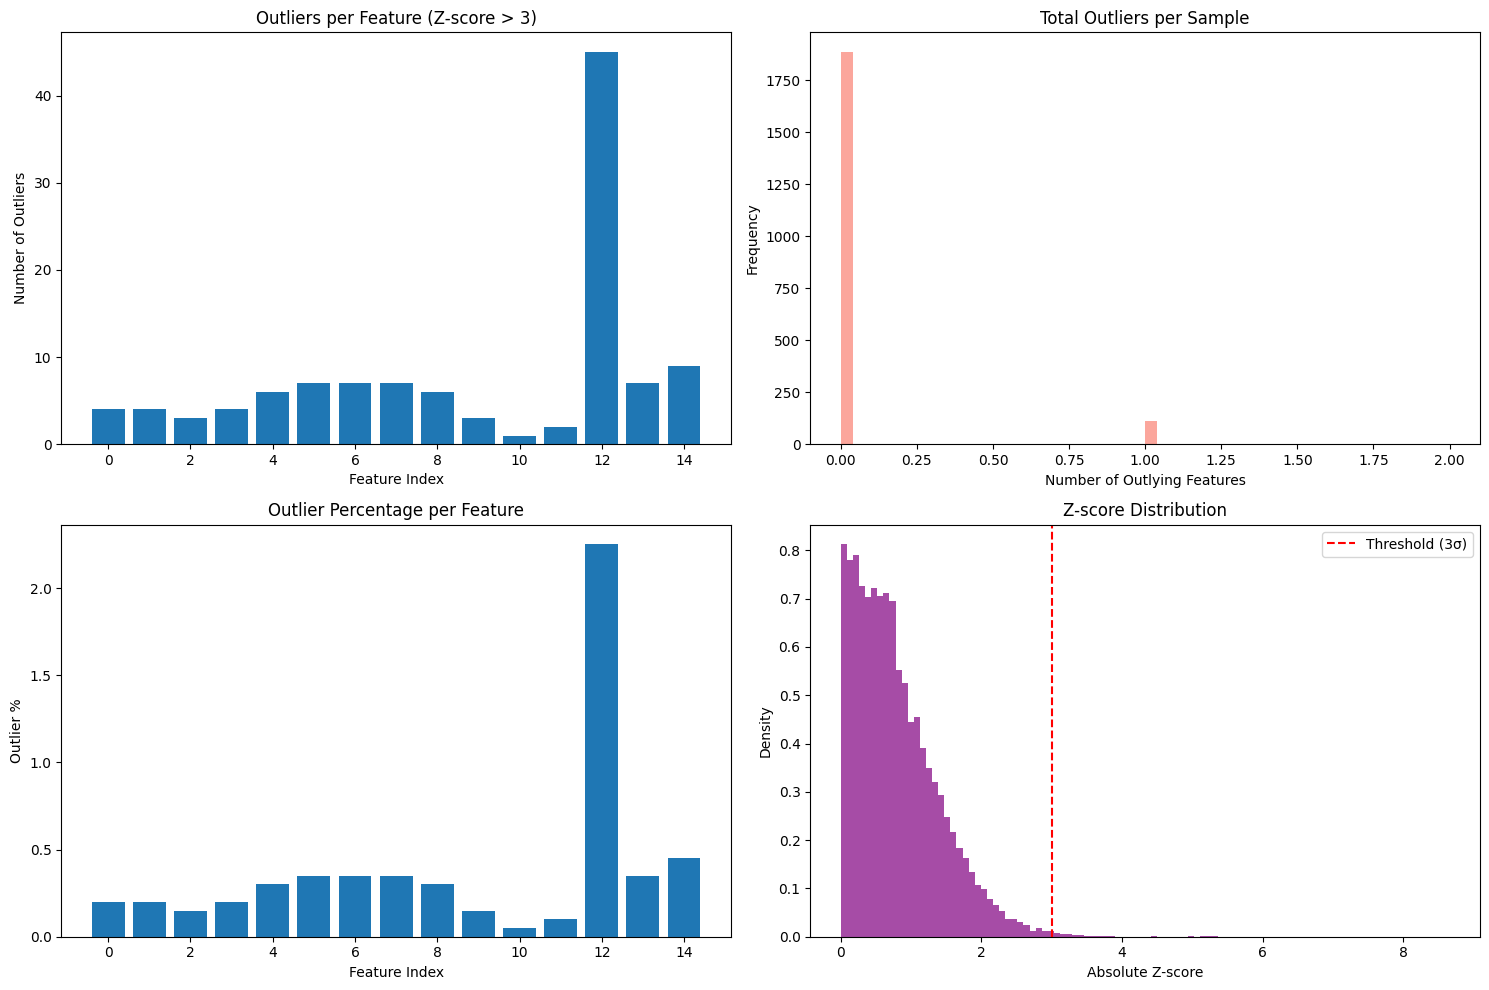

Total outliers detected: 115
Outlier percentage: 0.38%


In [10]:
# Z-score outlier detection
z_scores = np.abs(stats.zscore(X))
outlier_threshold = 3

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Outliers per feature
outliers_per_feature = np.sum(z_scores > outlier_threshold, axis=0)
axes[0, 0].bar(range(len(outliers_per_feature)), outliers_per_feature)
axes[0, 0].set_title('Outliers per Feature (Z-score > 3)')
axes[0, 0].set_xlabel('Feature Index')
axes[0, 0].set_ylabel('Number of Outliers')

# Total outliers per sample
total_outliers = np.sum(z_scores > outlier_threshold, axis=1)
axes[0, 1].hist(total_outliers, bins=50, alpha=0.7, color='salmon')
axes[0, 1].set_title('Total Outliers per Sample')
axes[0, 1].set_xlabel('Number of Outlying Features')
axes[0, 1].set_ylabel('Frequency')

# Outlier percentage per feature
outlier_pct = 100 * outliers_per_feature / X.shape[0]
axes[1, 0].bar(range(len(outlier_pct)), outlier_pct)
axes[1, 0].set_title('Outlier Percentage per Feature')
axes[1, 0].set_xlabel('Feature Index')
axes[1, 0].set_ylabel('Outlier %')

# Z-score distribution
axes[1, 1].hist(z_scores.flatten(), bins=100, alpha=0.7, color='purple', density=True)
axes[1, 1].axvline(outlier_threshold, color='red', linestyle='--', label='Threshold (3σ)')
axes[1, 1].set_title('Z-score Distribution')
axes[1, 1].set_xlabel('Absolute Z-score')
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

total_outliers_count = np.sum(z_scores > outlier_threshold)
print(f"Total outliers detected: {total_outliers_count}")
print(f"Outlier percentage: {100 * total_outliers_count / X.size:.2f}%")

In [11]:
def recover_p_true(p_vasya, k):
    exp_z = (2 * np.pi * k / (k - p_vasya) + p_vasya - 1) / (1 - p_vasya)
    p_true = 1 / (1 + 1 / exp_z)
    return p_true

In [12]:
import scipy.optimize as opt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

def neg_log_likelihood(k, X, p_vasya):
    try:
        p_true = recover_p_true(p_vasya, k)
        p_true = np.clip(p_true, 1e-15, 1 - 1e-15)
        model = LogisticRegression(fit_intercept=True, max_iter=1000)
        model.fit(X, (p_true > 0.5).astype(int))
        pred_probs = model.predict_proba(X)[:, 1]
        pred_probs = np.clip(pred_probs, 1e-15, 1 - 1e-15)
        nll = -np.mean(p_true * np.log(pred_probs) + (1 - p_true) * np.log(1 - pred_probs))
        return nll
    except:
        return np.inf

initial_k = 1.0
bounds = (0.1, 1000)  # Fixed: Two-element tuple with finite upper bound
result = opt.minimize_scalar(neg_log_likelihood, args=(X, p_vasya), bounds=bounds, method='bounded', options={'xatol': 1e-6})
k_opt = result.x
print("Optimized k:", k_opt)
print("Min NLL:", result.fun)

Optimized k: 0.10000043320813883
Min NLL: 0.15965801559565646


In [13]:
p_true = recover_p_true(p_vasya, k_opt)
print("Sample p_true values:", p_true[:5])
Y = (p_true > 0.5).astype(int)
print("Sample Y values:", Y[:5])
print("Class balance in Y: 0s =", np.sum(Y == 0), ", 1s =", np.sum(Y == 1))
print("\nFirst 5 p_vasya vs p_true:")
for i in range(5):
    print(f"{p_vasya[i]:.4f} -> {p_true[i]:.4f} -> Y={Y[i]}")

Sample p_true values: [-6.26124448e+06 -6.13142907e+06  8.49367337e-01 -6.26124461e+06
 -6.26124263e+06]
Sample Y values: [0 0 1 0 0]
Class balance in Y: 0s = 1695 , 1s = 305

First 5 p_vasya vs p_true:
1984.0000 -> -6261244.4825 -> Y=0
1963.3307 -> -6131429.0710 -> Y=0
0.0049 -> 0.8494 -> Y=1
1984.0000 -> -6261244.6131 -> Y=0
1983.9997 -> -6261242.6284 -> Y=0


In [14]:
import pandas as pd
submission = pd.DataFrame({'index': range(len(Y)),'Target': Y})
submission.to_csv('nine_submission.csv', index=False)
print("Submission file saved as 'submission.csv'")
print(submission.head())

Submission file saved as 'submission.csv'
   index  Target
0      0       0
1      1       0
2      2       1
3      3       0
4      4       0


# Version 2

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from scipy.special import expit
import scipy.optimize as opt
import warnings
warnings.filterwarnings('ignore')

data = np.load("/kaggle/input/linear-regression-competitive-ml-letovo/task_data.npz")
X = data["X"]
p_vasya = data["p_vasya"]
print(f"X shape: {X.shape}")
print(f"p_vasya shape: {p_vasya.shape}")
print(f"X dtype: {X.dtype}, p_vasya dtype: {p_vasya.dtype}")
print(f"Sample X[0]: {X[0]}")
print(f"Sample p_vasya[0]: {p_vasya[0]}")
p_vasya_norm = p_vasya / p_vasya.max()
print(f"Normalized p_vasya stats: Min {p_vasya_norm.min():.4f}, Max {p_vasya_norm.max():.4f}, Mean {p_vasya_norm.mean():.4f}")

X shape: (2000, 15)
p_vasya shape: (2000,)
X dtype: float64, p_vasya dtype: float64
Sample X[0]: [ 3.97685555e-01 -1.91013584e-01  6.18337118e-01  1.53051330e+00
 -1.82945258e-01 -1.99430160e-01  1.52024658e+00  7.48849116e-01
 -4.65655606e-01  5.29449687e-01  3.67309824e-01  5.96306790e-01
  9.09033304e-04 -1.93342724e+00 -1.87957912e+00]
Sample p_vasya[0]: 1983.9999755679498
Normalized p_vasya stats: Min 0.0000, Max 1.0000, Mean 0.7728


In [16]:
def argumented_data() -> pd.DataFrame():
    gm = GaussianMixture(n_components=2)
    gm.fit(df)
    syntetic_data, _ = gm.sample(300)
    X_new = pd.concat( [pd.DataFrame(X), pd.DataFrame(syntetic_data[:,:15])])
    return X_new

In [17]:
kmeans = KMeans(n_clusters=2, max_iter=500,random_state=42, n_init='auto')
kmeans.fit(X)
cluster_labels = kmeans.fit_predict(X)

unique, counts = np.unique(cluster_labels, return_counts=True)
print(f"Clusters: {dict(zip(unique, counts))}")

counts = np.bincount(cluster_labels)
minority_label = np.argmin(counts)
pseudo_labels = (cluster_labels == minority_label).astype(int)

Clusters: {0: 1690, 1: 310}


In [18]:
clf = LogisticRegression(max_iter=1000,
                         class_weight='balanced',
                         penalty='l2',
                         solver='liblinear',
                         C=0.8)
clf.fit(X, pseudo_labels)
probs = clf.predict_proba(X)[:,1]

In [19]:
sub = pd.read_csv('/kaggle/input/linear-regression-competitive-ml-letovo/sample_submission.csv')

sub['Target'] = (probs >= 0.25).astype(int)
sub.to_csv('submission.csv',index=False)

In [20]:
sub['Target'].value_counts()

Target
0    1583
1     417
Name: count, dtype: int64

# Version 3

In [21]:
import numpy as np
import pandas as pd
from scipy.special import expit
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# =========================
#  Load dataset
# =========================
data = np.load("/kaggle/input/linear-regression-competitive-ml-letovo/task_data.npz")
X = data["X"]
p_vasya = data["p_vasya"]

print(f"✅ Data loaded — X shape: {X.shape}, p_vasya shape: {p_vasya.shape}")
print(f"p_vasya range: [{p_vasya.min():.4f}, {p_vasya.max():.4f}]")
print(f"Histogram counts: {np.histogram(p_vasya, bins=10)[0]}")

# =========================
#  Custom sigmoid variants
# =========================
def recover_z_formula1(p_vasya, a, pi=np.pi):
    """Formula 1: p_vasya = a / (1 + pi * e^(-z))"""
    p_vasya_clipped = np.clip(p_vasya, 1e-10, a * (1 - 1e-10))
    term = (a / p_vasya_clipped) - 1
    z = -np.log(np.clip((1 / pi) * term, 1e-10, 1e10))
    return z

def recover_z_formula2(p_vasya, a, pi=np.pi):
    """Formula 2: p_vasya = a / (1 + e^(-z / pi))"""
    p_vasya_clipped = np.clip(p_vasya, 1e-10, a * (1 - 1e-10))
    term = (a / p_vasya_clipped) - 1
    z = -pi * np.log(np.clip(term, 1e-10, 1e10))
    return z

def recover_z_formula3(p_vasya, a, pi=np.pi):
    """Formula 3: p_vasya = a / (1 + e^(-pi * z))"""
    p_vasya_clipped = np.clip(p_vasya, 1e-10, a * (1 - 1e-10))
    term = (a / p_vasya_clipped) - 1
    z = -(1 / pi) * np.log(np.clip(term, 1e-10, 1e10))
    return z

def recover_z_formula4(p_vasya, a, pi=np.pi):
    """Formula 4: p_vasya = a / (pi * e^(-z))"""
    p_vasya_clipped = np.clip(p_vasya, 1e-10, a * (1 - 1e-10))
    z = -np.log(p_vasya_clipped / (a / pi))
    return z

# =========================
#  Search for best formula
# =========================
a_candidates = [p_vasya.max(), 1.0, 10.0, 42.0, 100.0, 1000.0]
formulas = [
    (recover_z_formula1, "Formula 1"),
    (recover_z_formula2, "Formula 2"),
    (recover_z_formula3, "Formula 3"),
    (recover_z_formula4, "Formula 4")
]

best_f1 = 0
best_y_pred = None
best_a = None
best_formula_name = None

for recover_z, formula_name in formulas:
    for a in a_candidates:
        z = recover_z(p_vasya, a)
        p_true = expit(z)
        y_pred = (z >= 0).astype(int)

        X_train, X_val, z_train, z_val = train_test_split(X, z, test_size=0.2, random_state=42)
        y_train = (z_train >= 0).astype(int)
        y_val = (z_val >= 0).astype(int)

        clf = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
        clf.fit(X_train, y_train)
        p_val = clf.predict_proba(X_val)[:, 1]
        y_val_pred = (p_val >= 0.5).astype(int)
        f1 = f1_score(y_val, y_val_pred)
        class_dist = np.bincount(y_pred)

        print(f"{formula_name}, a={a:.4f}, F1={f1:.4f}, Class dist={class_dist}")

        # Choose best based on F1 and class balance
        if f1 > best_f1 and 100 <= class_dist[1] <= 500:
            best_f1 = f1
            best_y_pred = y_pred
            best_a = a
            best_formula_name = formula_name

# Fallback: use best F1 if no balanced case found
if best_a is None:
    for recover_z, formula_name in formulas:
        for a in a_candidates:
            z = recover_z(p_vasya, a)
            p_true = expit(z)
            y_pred = (z >= 0).astype(int)
            X_train, X_val, z_train, z_val = train_test_split(X, z, test_size=0.2, random_state=42)
            y_train = (z_train >= 0).astype(int)
            y_val = (z_val >= 0).astype(int)
            clf = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
            clf.fit(X_train, y_train)
            p_val = clf.predict_proba(X_val)[:, 1]
            y_val_pred = (p_val >= 0.5).astype(int)
            f1 = f1_score(y_val, y_val_pred)
            if f1 > best_f1:
                best_f1 = f1
                best_y_pred = y_pred
                best_a = a
                best_formula_name = formula_name

print(f"\n✅ Best configuration: {best_formula_name}, a={best_a:.4f}, Validation F1={best_f1:.4f}")

# =========================
#  Final reconstruction
# =========================
formula_map = {
    "Formula 1": recover_z_formula1,
    "Formula 2": recover_z_formula2,
    "Formula 3": recover_z_formula3,
    "Formula 4": recover_z_formula4
}

z = formula_map[best_formula_name](p_vasya, best_a)

# Tune logit shift to balance positive ratio (10–15%)
best_shift = None
best_shift_f1 = 0
percentile_candidates = np.linspace(80, 90, 11)

for pctl in percentile_candidates:
    shift = np.percentile(z, pctl)
    z_shifted = z - shift
    preds = (z_shifted >= 0).astype(int)
    ratio = preds.mean()
    pseudo_f1 = f1_score(preds, (z >= 0).astype(int))
    if pseudo_f1 > best_shift_f1:
        best_shift_f1 = pseudo_f1
        best_shift = shift

print(f"Optimal logit shift ≈ {best_shift:.3f} (pseudo F1={best_shift_f1:.4f})")

# Apply best shift
z_final = z - best_shift
p_true_final = expit(z_final)
y_pred_final = (z_final >= 0).astype(int)

print(f"Final class distribution: {np.bincount(y_pred_final)}")

# =========================
#  Save submission
# =========================
sub = pd.read_csv('/kaggle/input/linear-regression-competitive-ml-letovo/sample_submission.csv')
sub['Target'] = y_pred_final
sub.to_csv('submission.csv', index=False)
print("🚀 Submission file 'submission.csv' saved successfully — ready to upload!")


✅ Data loaded — X shape: (2000, 15), p_vasya shape: (2000,)
p_vasya range: [0.0000, 1984.0000]
Histogram counts: [ 397   19    9   12   13   10   19   11   33 1477]
Formula 1, a=1984.0000, F1=0.9857, Class dist=[ 418 1582]
Formula 1, a=1.0000, F1=0.9838, Class dist=[ 272 1728]
Formula 1, a=10.0000, F1=0.9880, Class dist=[ 314 1686]
Formula 1, a=42.0000, F1=0.9878, Class dist=[ 344 1656]
Formula 1, a=100.0000, F1=0.9815, Class dist=[ 361 1639]
Formula 1, a=1000.0000, F1=0.9874, Class dist=[ 399 1601]
Formula 2, a=1984.0000, F1=0.9904, Class dist=[ 450 1550]
Formula 2, a=1.0000, F1=0.9866, Class dist=[ 288 1712]
Formula 2, a=10.0000, F1=0.9834, Class dist=[ 331 1669]
Formula 2, a=42.0000, F1=0.9801, Class dist=[ 358 1642]
Formula 2, a=100.0000, F1=0.9876, Class dist=[ 375 1625]
Formula 2, a=1000.0000, F1=0.9857, Class dist=[ 419 1581]
Formula 3, a=1984.0000, F1=0.9904, Class dist=[ 450 1550]
Formula 3, a=1.0000, F1=0.9866, Class dist=[ 288 1712]
Formula 3, a=10.0000, F1=0.9834, Class dis